## Introdução:

No contexto da unidade curricular de aprendizagem automática supervisionada, realizamos o presente trabalho visando aplicar os conhecimentos adquiridos ao longo das aulas, sendo este a primeira tutoria em grupo, será subdividida nas seguintes partes:

Indíce:

O trabalho vai ser dividido nas seguintes partes:

1. Definição do problema

2. Aquisição dos dados

3. Data Wrangling - Limpeza e manipulação do dataset de forma a obter novas variáveis para poder analisar

4. EDA - Análise exploratória dos dados e a sua interpretação

5. Modelação preditiva - Criação de algoritmos de machine learning

6. Conclusão

## 1. Definição do problema

O objetivo deste projeto é prever o valor total gasto por cliente em uma compra com base em um conjunto de variáveis fornecidas no dataset. Este problema se enquadra na categoria de regressão, já que a variável-alvo, o valor total gasto, é contínua.

Através da exploração dos dados e do uso de técnicas de Data Wrangling e Análise Exploratória de Dados (EDA), o dataset será preparado para ser dividido em dois subconjuntos: um para treino e outro para teste. Após o pré-processamento, utilizaremos modelos de Regressão Linear para prever o valor das compras e Regressão Logística para outros cenários de classificação (se aplicável). (a melhorar)



## 2. Aquisição dos dados

Este dataset foi retirado do site www.dataworld.com, nomeadamente pelo seguinte link : https://data.world/mitcholsmo/supermarket-sales com o intuito de realizar a primeira tutoria em grupo de supervised machine learning.

## 3. Data Wrangling

Segue-se a importação de todas as biblotecas que se irão utilizar neste trabalho:

In [156]:
import pandas as pd
import numpy 
import matplotlib
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression #logistic regression
from sklearn.model_selection import train_test_split, GridSearchCV #training and testing data split
from sklearn import metrics #accuracy measure
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix #for confusion matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, accuracy_score, precision_score
warnings.filterwarnings('ignore')
%matplotlib inline

Em primeira mão conseguimos observar que o mesmo esta dividido em 1000 instãncias, repartido pelas seguintes colunas: total (valor total pago sem desconto), discount (valor total pago após desconto, visto serem números inteiros em cada instância, trata-se em alguns casos de dados do tipo float arredondados para dar inteiro.
Também se consegue observar as variáveis "Quantity", referente a quantidade de produtos comprados, "bags" referentes aos sacos utilizados, "rating" categorizada de 1 a 5 (satisfação do cliente/avaliação). A coluna (variável) staff refere-se ao número de funcionários presentes na loja, "outlet" refere-se ao número correspondente da cadeia, repartido em A, B e C.
Gender refere-se ao sexo do/a comprador/a e "payment", respetivamente ao método de pagamento escolhido pelo mesmo no ato da compra, sendo disponíveis apenas numerário e cartão debito/crédito.

Variáveis iniciais em estudo utilizando o seguinte código:

In [160]:
sales = pd.read_csv("sales.csv")
print(sales.dtypes)

total         float64
 discount       int64
quantity        int64
bags            int64
rating          int64
staff           int64
outlet         object
gender         object
payment        object
dtype: object


### Variáveis

1º - total - pagamento após desconto aplicado - float

2º - discount - total do valor de desconto efectuado - float, #correção é apresentado em int

3º - quantity - nº de produtos comprados - int

4º - bags - nº de sacos pedidos - int ##corta

5º - rating - avaliação dada pelo cliente 1 or 2 or 3 or 4 or 5 - int

6º - staff - nº de funcionários no supermercado no momento da venda - int

7º - outlet - supermercado "A", "B", "C" ##corta

8º- gender - sexo do cliente - "Male", "Female"

9º- payment - método de pagamento - "Credit", "Cash" 

Algumas observações iniciais quanto ao tipo de variáveis iniciais do dataset em estudo. Conta-se 9 váriaveis sendo 5 do tipo int, uma do tipo float e 3 variáveis do tipo objeto. Das quais Total sendo uma variável quantitativa contínua. Desconto uma variável contínua (tirando o facto de ser valor arredondado para inteiro), quantity, bags, staff variáveis quantitativas discretas. Método de pagamento (payment) e genéro (gender) variáveis qualititativa nominais, rating variável qualitativa ordinal e outlet variáveis qualitativas nominais. 

In [164]:
print(sales.head())
print(sales.describe())
print(sales.value_counts())

    total   discount   quantity  bags  rating  staff outlet  gender payment
0  103.25          99        12     6       4      5      A  Female  Credit
1   60.65          59         6     0       4      3      C  Female    Cash
2   88.58          44         8     7       3      7      A    Male    Cash
3   92.30          98         8     3       5      3      A    Male  Credit
4   75.88          76         8     3       4      5      A    Male    Cash
            total    discount      quantity         bags       rating  \
count  1000.00000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     85.46060    60.759000     9.033000     3.491000     3.435000   
std      22.86183    22.915541     2.035203     2.285857     0.917942   
min      30.36000    20.000000     3.000000     0.000000     1.000000   
25%      68.96500    41.000000     8.000000     1.000000     3.000000   
50%      85.32000    62.000000     9.000000     4.000000     3.000000   
75%     101.44250    80.000000   

Procedimento adotado no data wrangling:
Dividir o valor da coluna desconto por 100 visto que se trata de cêntimos.
Criação da coluna "total_bruto" tratando-se do valor total sem desconto aplicado.
Criação da coluna "discount_percentage", sendo esta o valor em % do desconto aplicado sobre o total pago.
Divisão do dataset pelos 3 outlets A, B e C.
Criação dos 3 subsets de cada outlet respetivo.

In [167]:
sales.columns = sales.columns.str.strip()
print(sales.head())

    total  discount  quantity  bags  rating  staff outlet  gender payment
0  103.25        99        12     6       4      5      A  Female  Credit
1   60.65        59         6     0       4      3      C  Female    Cash
2   88.58        44         8     7       3      7      A    Male    Cash
3   92.30        98         8     3       5      3      A    Male  Credit
4   75.88        76         8     3       4      5      A    Male    Cash


In [169]:
#Criar a coluna 'total_bruto' (valor antes do desconto)
sales['total_bruto'] = sales['total'] + sales['discount']

In [171]:
#Converter valores de pennies para libras (ou a unidade desejada)
sales['discount'] = sales['discount'] / 100

In [173]:
#Criar a coluna 'total_bruto' (valor antes do desconto)
sales['total_bruto'] = sales['total'] + sales['discount']

In [175]:
#Criar a coluna 'discount_percentage' (% de desconto concedido)
sales['discount_percentage'] = (sales['discount'] / sales['total_bruto']) * 100

In [177]:
# Remover as colunas 'outlet' e 'bags' devido a não servirem para o contexto que iremos estudar
sales = sales.drop(columns=['outlet', 'bags'])


In [179]:
print(sales.head())

    total  discount  quantity  rating  staff  gender payment  total_bruto  \
0  103.25      0.99        12       4      5  Female  Credit       104.24   
1   60.65      0.59         6       4      3  Female    Cash        61.24   
2   88.58      0.44         8       3      7    Male    Cash        89.02   
3   92.30      0.98         8       5      3    Male  Credit        93.28   
4   75.88      0.76         8       4      5    Male    Cash        76.64   

   discount_percentage  
0             0.949731  
1             0.963423  
2             0.494271  
3             1.050600  
4             0.991649  


## 4. EDA - Análise exploratória dos dados e a sua interpretação

In [182]:
#Criação de uma nova variável/coluna para a interação entre quantidade de artigos e o desconto aplicado por artigo
sales['quantity_discount_interaction'] = sales['discount'] / sales['quantity']

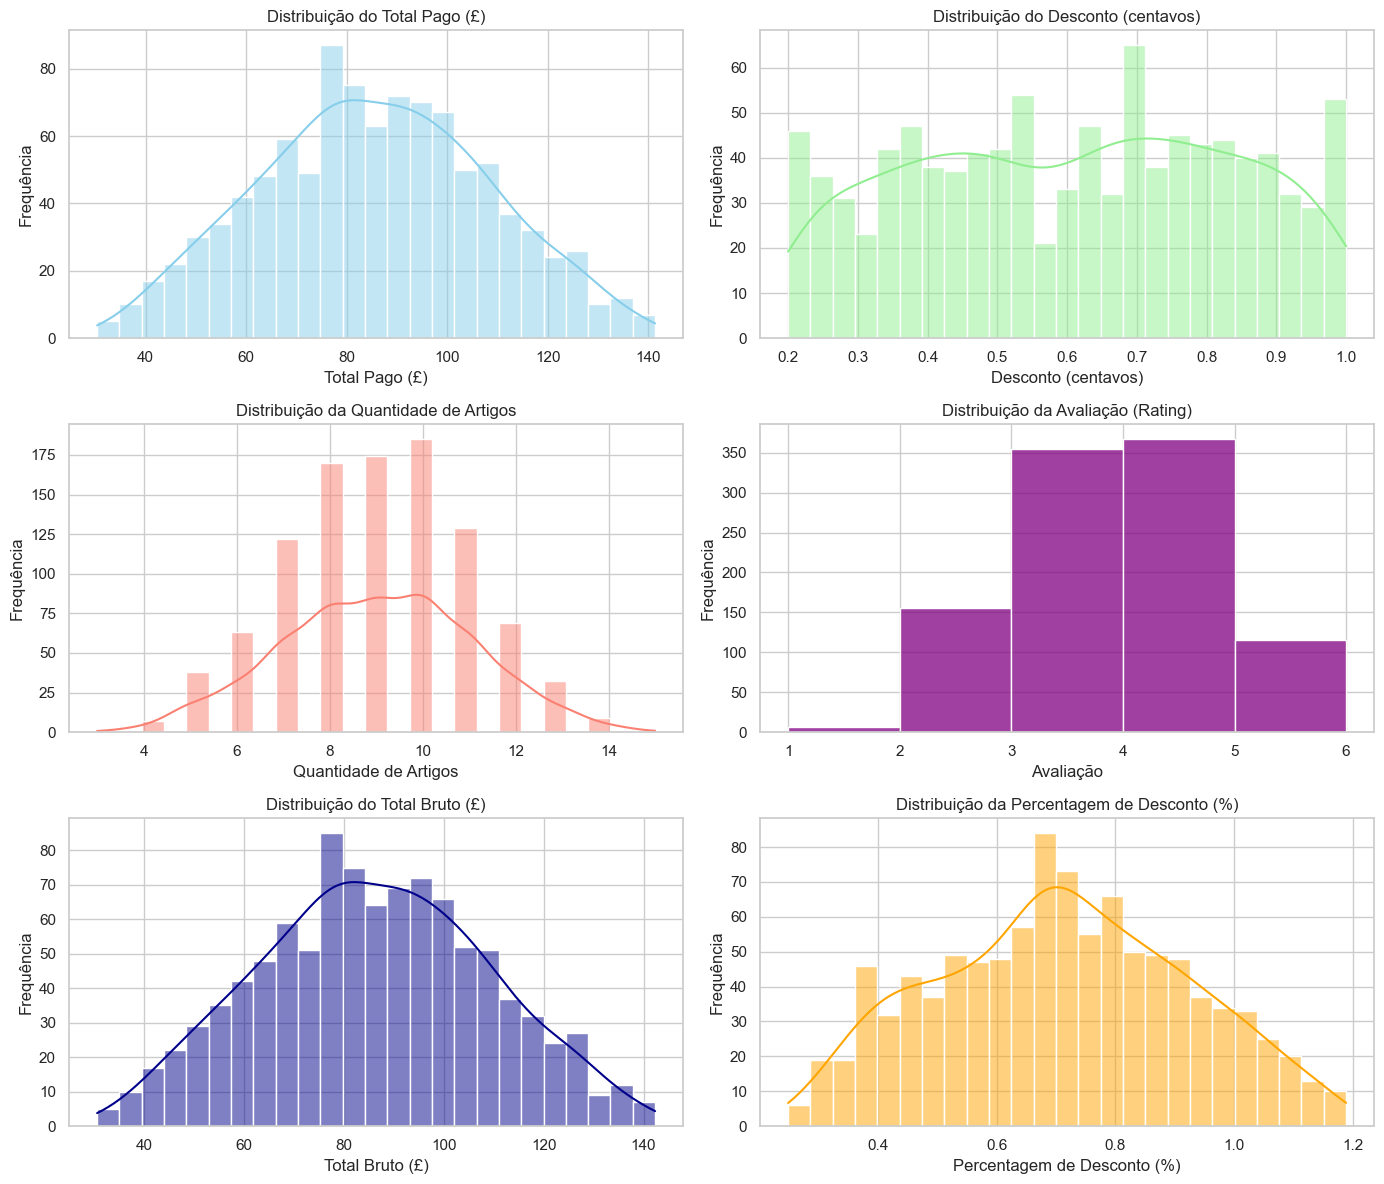

In [184]:
# Configuração do estilo dos gráficos
sns.set(style="whitegrid")

# Criar subplots para as variáveis numéricas
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# Histograma para o Total Pago
sns.histplot(sales['total'], bins=25, kde=True, ax=axs[0, 0], color='skyblue')
axs[0, 0].set_title('Distribuição do Total Pago (£)')
axs[0, 0].set_xlabel('Total Pago (£)')
axs[0, 0].set_ylabel('Frequência')

# Histograma para o Desconto
sns.histplot(sales['discount'], bins=25, kde=True, ax=axs[0, 1], color='lightgreen')
axs[0, 1].set_title('Distribuição do Desconto (centavos)')
axs[0, 1].set_xlabel('Desconto (centavos)')
axs[0, 1].set_ylabel('Frequência')

# Histograma para a Quantidade de Artigos
sns.histplot(sales['quantity'], bins=25, kde=True, ax=axs[1, 0], color='salmon')
axs[1, 0].set_title('Distribuição da Quantidade de Artigos')
axs[1, 0].set_xlabel('Quantidade de Artigos')
axs[1, 0].set_ylabel('Frequência')

# Histograma para Avaliação (Rating)
sns.histplot(sales['rating'], bins=5, kde=False, ax=axs[1, 1], color='purple')
axs[1, 1].set_title('Distribuição da Avaliação (Rating)')
axs[1, 1].set_xlabel('Avaliação')
axs[1, 1].set_ylabel('Frequência')

# Histograma para o Total Bruto
sns.histplot(sales['total_bruto'], bins=25, kde=True, ax=axs[2, 0], color='darkblue')
axs[2, 0].set_title('Distribuição do Total Bruto (£)')
axs[2, 0].set_xlabel('Total Bruto (£)')
axs[2, 0].set_ylabel('Frequência')

# Histograma para Percentagem de Desconto
sns.histplot(sales['discount_percentage'], bins=25, kde=True, ax=axs[2, 1], color='orange')
axs[2, 1].set_title('Distribuição da Percentagem de Desconto (%)')
axs[2, 1].set_xlabel('Percentagem de Desconto (%)')
axs[2, 1].set_ylabel('Frequência')

# Ajustar o layout
plt.tight_layout()
plt.show()

No que toca a densidade dos valores pagos, segue o desvio padrão normal, no meio isto é, nos valores centrais dos valores registados encontra-se os valores com mais ocorrências sendo o intervalo 80-100€ o intervalo se agrupado com maior número de registos.
De entoar que em termos de desconto liquido, este regista maiores ocorrências em valores mais baixos para descontos menores, decresce para os valores medianos e volta a aumentar as ocorrências para maiores descontos. 
Em relação as classificações no geral existe maior número de clientes com satisfação moderada/alta, aliado ao facto das maiores receitas virem por parte das mulheres tanto que a maior densidade de ocorrências de quantidade de artigos por compra centrarem-se em vários artigos sugere-se foco em campanhas de marketing de produtos com foco nestas.

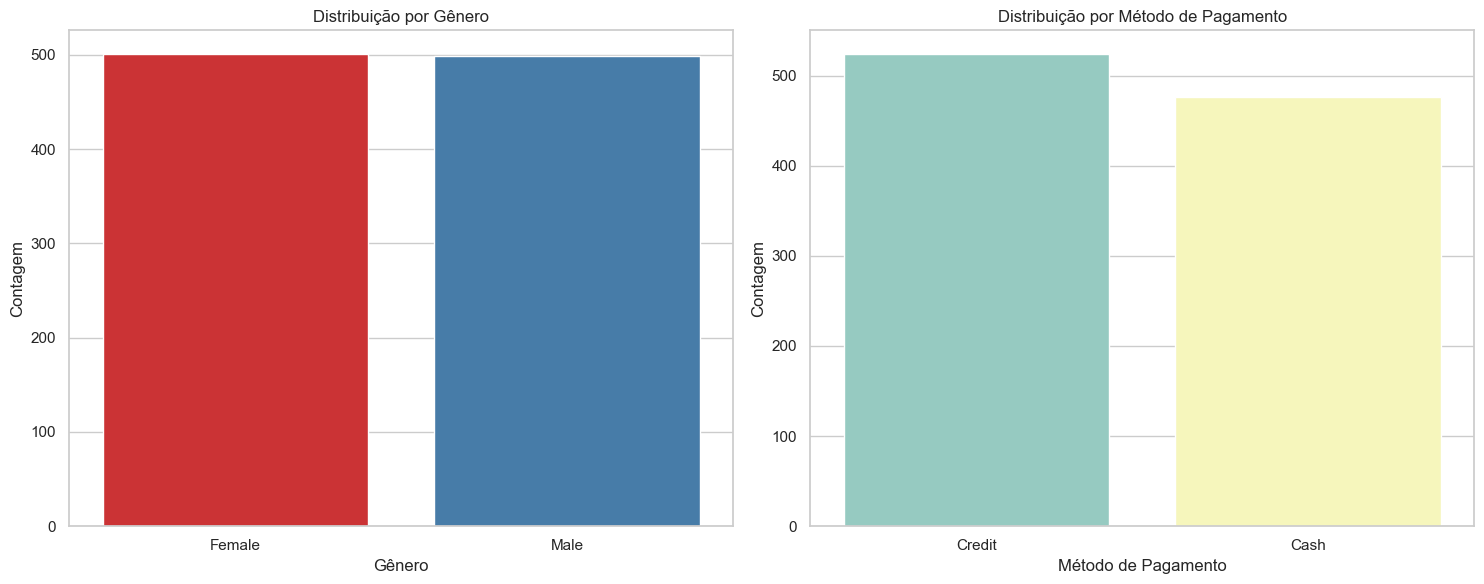

In [186]:
# Criar subplots para as variáveis categóricas
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de contagem para Gênero
sns.countplot(x='gender', data=sales, ax=axs[0], palette='Set1')
axs[0].set_title('Distribuição por Gênero')
axs[0].set_xlabel('Gênero')
axs[0].set_ylabel('Contagem')

# Gráfico de contagem para Método de Pagamento
sns.countplot(x='payment', data=sales, ax=axs[1], palette='Set3')
axs[1].set_title('Distribuição por Método de Pagamento')
axs[1].set_xlabel('Método de Pagamento')
axs[1].set_ylabel('Contagem')

# Ajustar o layout
plt.tight_layout()
plt.show()

O número de clientes é igual para ambos os sexos, o que não consta com o método de pagamento preferido por uma margem de 50 ocorrências, sendo superior a opção cartão de crédito/débito.


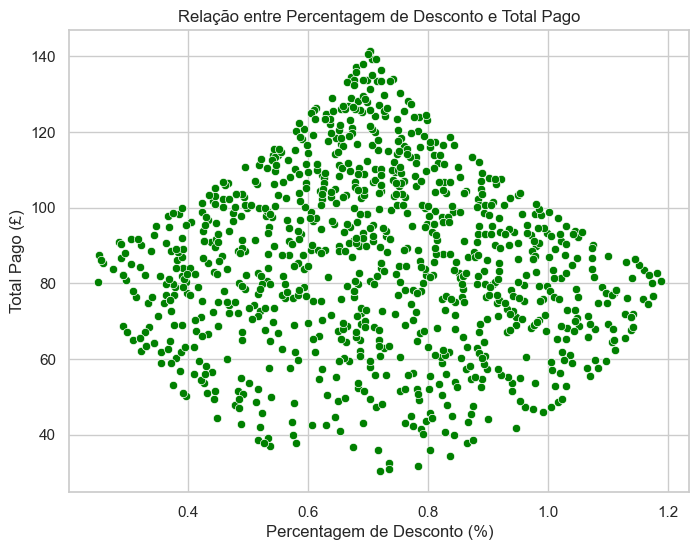

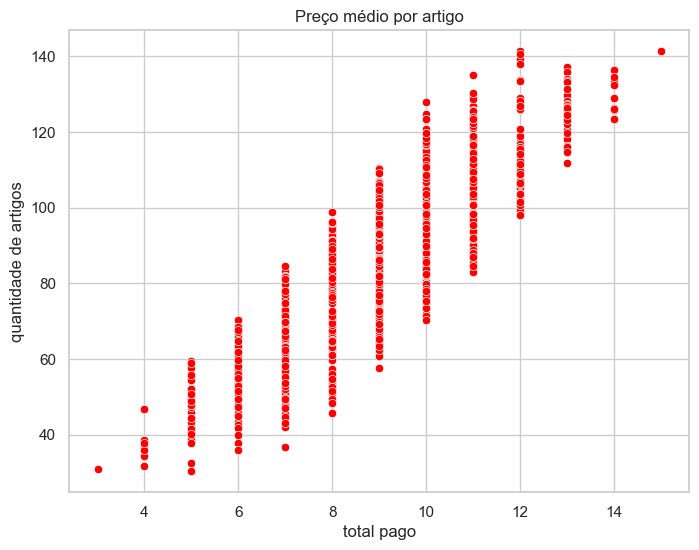

In [188]:
# Scatter Plot - Relação entre 'discount_percentage' e 'total'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='discount_percentage', y='total', data=sales, color='green')
plt.title('Relação entre Percentagem de Desconto e Total Pago')
plt.xlabel('Percentagem de Desconto (%)')
plt.ylabel('Total Pago (£)')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='quantity', y='total', data= sales, color= 'red')
plt.title('Preço médio por artigo')
plt.xlabel('total pago')
plt.ylabel('quantidade de artigos')
plt.show()

É de realçar que a concentração dos valores de maior desconto aplicado sobre o total pago concentração no intervalo 0.6 e 1% sendo os valores de maior desconto sobre o total em compras de valores intermédios o que se pode notar que são compras de para tempo de curta duração visto que para uma pessoa solteira nos dias de hoje 60-80€ representa mais ou menos metade dos gastos em supermercado, fundamento esta observação de que a quantidade de artigos comprados nos 3 supermercados ir de 1 a 15 centrando-se na média dos 8/9 artigos por cliente. 

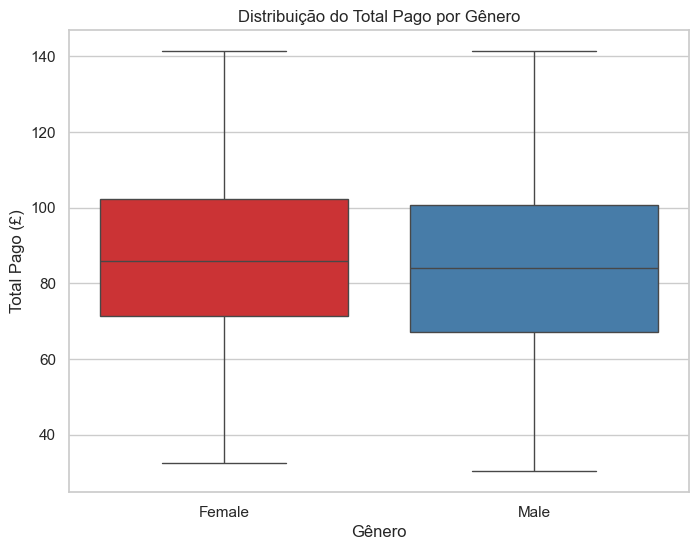

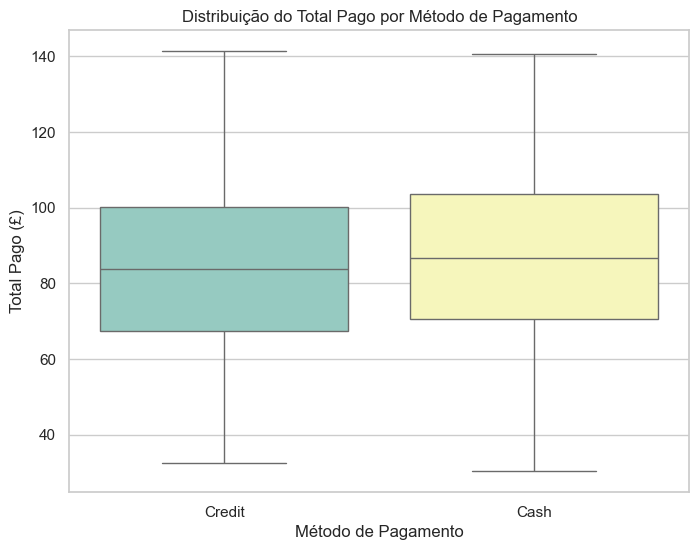

In [190]:
# Boxplot - Total Pago por Gênero
plt.figure(figsize=(8, 6))
sns.boxplot(x='gender', y='total', data=sales, palette='Set1')
plt.title('Distribuição do Total Pago por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Total Pago (£)')
plt.show()

# Boxplot - Total Pago por Método de Pagamento
plt.figure(figsize=(8, 6))
sns.boxplot(x='payment', y='total', data=sales, palette='Set3')
plt.title('Distribuição do Total Pago por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Total Pago (£)')
plt.show()

Algumas observações possíveis a retirar destes gráficos:
Por uma margem pequena o Outlet A pervalece diante dos outros 2 por uma margem pequena, porém em contas finais em lucro este obtém mais margem sob os outros.
Em termos de gastos por género as mulheres tendem a gastar um pouco mais que os homens no domínio em estudo, como tambbém pagam valores mais altos sobre as suas compras efectuadas, o que pode servir de base para focar a atenção do marketing especialmente nos produtos normalmente com vendas superiores neste género. Bem como as campanhas publicitárias serem direcionadas com foco nestas observações. 
Enquanto ao método de pagamento o numerário prevalece como escolhidos em compras de maior valor.

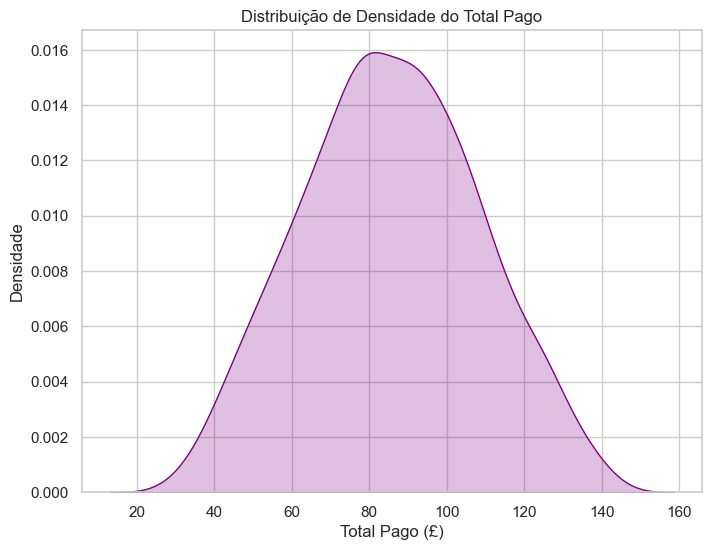

In [192]:
# Gráfico de Densidade para o Total Pago
plt.figure(figsize=(8, 6))
sns.kdeplot(sales['total'], color='purple', shade=True)
plt.title('Distribuição de Densidade do Total Pago')
plt.xlabel('Total Pago (£)')
plt.ylabel('Densidade')
plt.show()

A densidade dos maiores valores regista-se no intervalo dos 80-100, com este gráfico a ilustrar efectivamente tal afirmação.

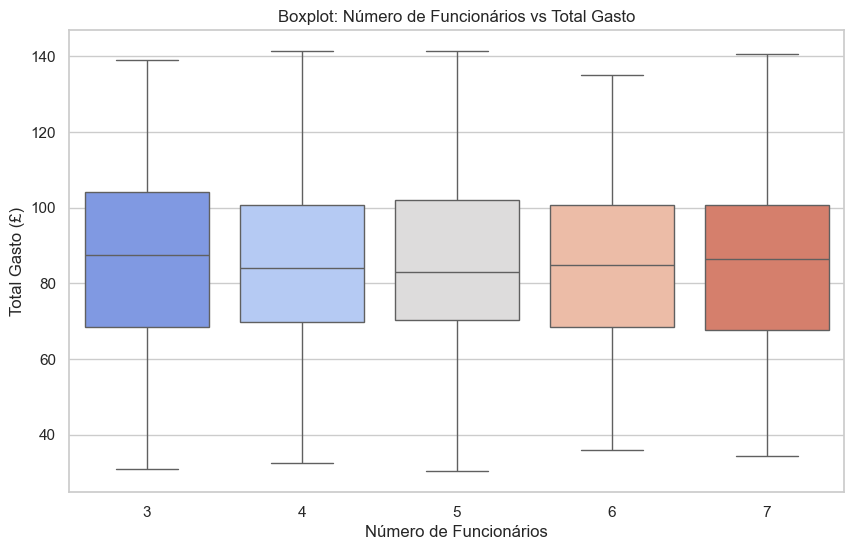

In [195]:
# Boxplot para ver a relação entre Staff e Total Gasto
plt.figure(figsize=(10,6))
sns.boxplot(x='staff', y='total', data=sales, palette='coolwarm')
plt.title('Boxplot: Número de Funcionários vs Total Gasto')
plt.xlabel('Número de Funcionários')
plt.ylabel('Total Gasto (£)')
plt.show()


O gráfico mostra que, nos outlets com mais funcionários, há uma leve tendência de gastos maiores, sugerindo que o atendimento pode ser um fator de influência nas compras.

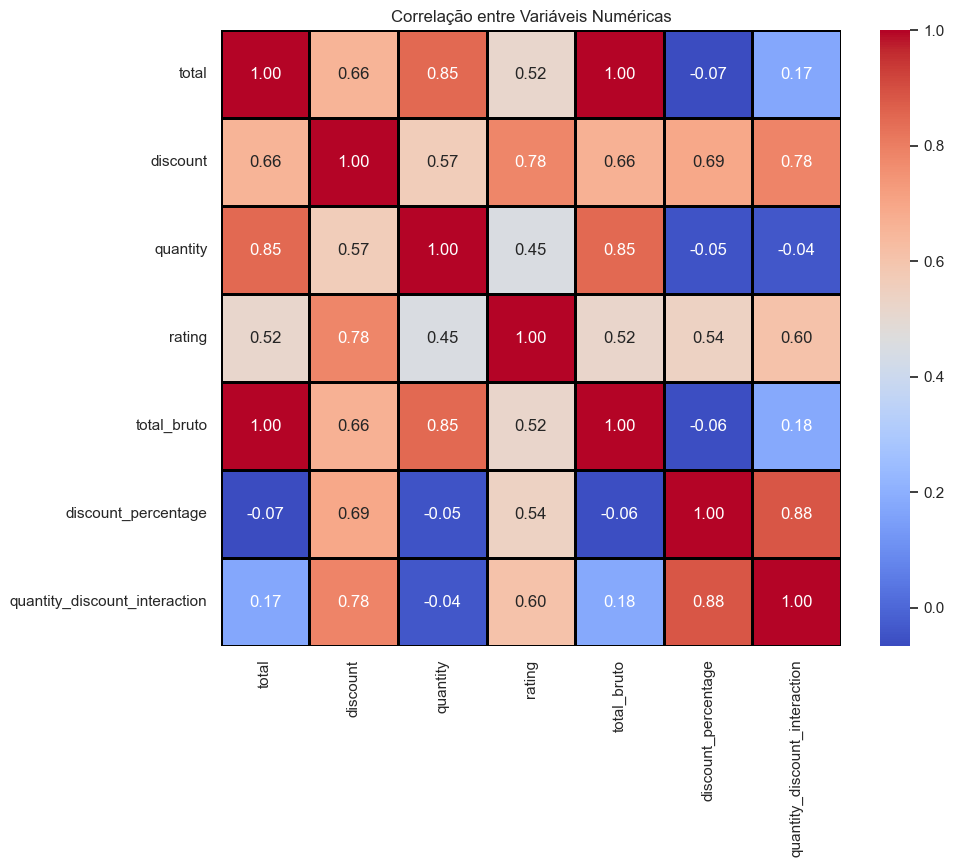

In [198]:
# Selecionar as variáveis numéricas relevantes para correlação
numeric_columns = ['total', 'discount', 'quantity', 'rating', 'total_bruto', 'discount_percentage', 'quantity_discount_interaction']

# Calcular a matriz de correlação
correlation_matrix = sales[numeric_columns].corr()

# Plotar a matriz de correlação usando heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=1, linecolor='black')
plt.title('Correlação entre Variáveis Numéricas')
plt.show()

No que toca ás correlação das variáveis quantitativas contínuas, as principais conclusões a retirar dos dados apresentados sáo uma forte ligação entre total e quantidade de artigos, o total com o desconto conferido. O rating e o desconto estabelecem forte ligação, sendo o valor dos preços praticados nos estabelecimento moderadamente correlacionado com a satisfação dos clientes visto que a densidade de artigos comprados rondar os 8/9 o que torna valores médios por artigo 8/9€, justifica a afirmação de não se tratarem de supermercados de venda de bens alimentares.

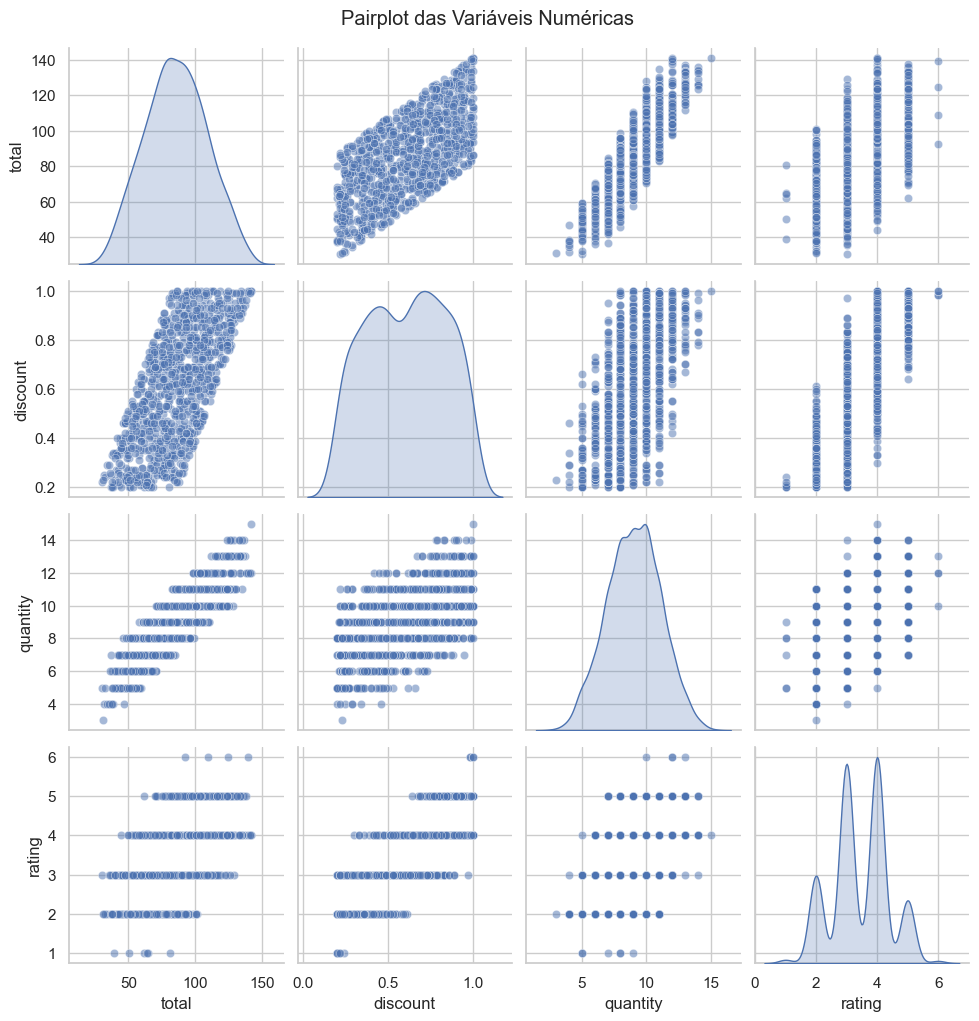

In [206]:
# Gráfico de Pares (pairplot) para variáveis numéricas selecionadas
sns.pairplot(sales[['total', 'discount', 'quantity', 'rating']], diag_kind='kde', kind='scatter', plot_kws={'alpha':0.5})
plt.suptitle('Pairplot das Variáveis Numéricas', y=1.02)
plt.show()


Relação Linear: Existe uma correlação linear clara entre o total pago (total) e o desconto (discount), indicando que maiores compras tendem a receber maiores descontos.
Quantidade e Total: A quantidade de itens comprados (quantity) está fortemente correlacionada com o total, sugerindo que o número de itens é um fator importante no valor total gasto.
Quantidade e Desconto: Clientes que compram mais itens tendem a receber maiores descontos.
Distribuições: A maioria das transações tem um valor entre 50 e 100, descontos menores que 1, e clientes compram entre 5 e 10 itens. As avaliações dos clientes são majoritariamente entre 3 e 5.
Rating: Não há correlação clara entre a avaliação (rating) e as demais variáveis, sugerindo que o valor gasto ou o desconto não afetam diretamente as avaliações.

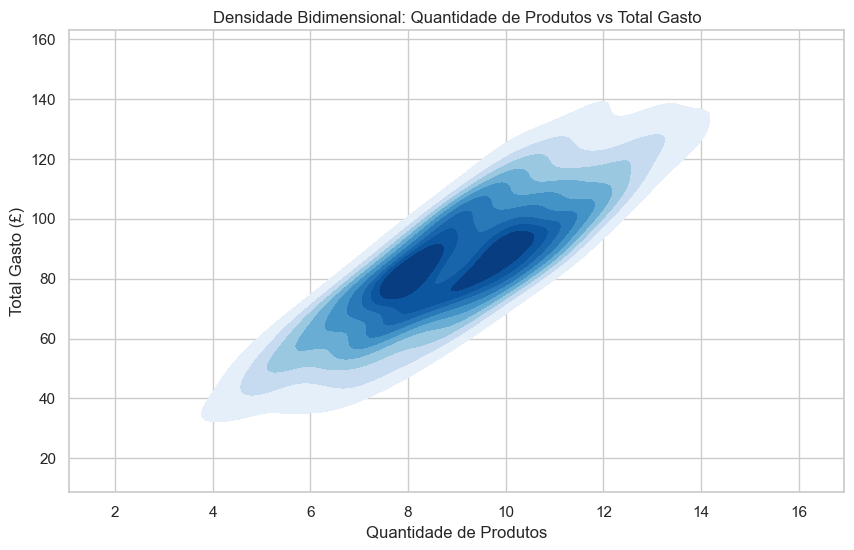

In [208]:
# Gráfico de Densidade 2D (Quantity vs Total)
plt.figure(figsize=(10,6))
sns.kdeplot(x='quantity', y='total', data=sales, cmap='Blues', fill=True, thresh=0.05)
plt.title('Densidade Bidimensional: Quantidade de Produtos vs Total Gasto')
plt.xlabel('Quantidade de Produtos')
plt.ylabel('Total Gasto (€)')
plt.show()

Este gráfico evidencia uma forte densidade de gastos concentrados em clientes que compram até 10 itens, mas para valores maiores de quantidade, o gasto total aumenta de forma mais pronunciada. Quantidade de produtos é uma das variáveis mais importantes para prever o total gasto.
O número de sacos também pode ser uma proxy interessante para o tamanho das compras e complementar a predição.
O número de funcionários pode impactar o total gasto, sugerindo que melhorar a experiência de atendimento pode aumentar as vendas.
Perfis de clientes variam entre outlets, mas as principais variáveis que afetam o total gasto (como quantidade de produtos) são consistentes.

## 5. Modelação preditiva, criação de algoritmos de machine learning

### Modelo regressão linear

Dividimos o data-set por 80/20, sendo os 80% as instâncias de treino e os outros 20% as instâncias de teste. E tentamos prever o total bruto gasto apartir do descontto, rating e sacos do cliente. Os valores do R-quadrado e do erro quadrado médio dão valores não muito bons e precisos para o nosso problema, podendo-se observar também pelo gráfico de dispersão que os pontos não estão muito próximos da reta de regressão.

In [141]:
# X e y são definidos como no seu código
sales_encoded = pd.get_dummies(sales, drop_first=True)
X = sales_encoded.drop(columns=['total', 'total_bruto', 'discount_percentage', 'quantity_discount_interaction'])
y = sales_encoded['total']

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Verificar as dimensões dos conjuntos
print(f"Tamanho do conjunto de treino: {X_train.shape[0]}")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]}")

# Criar o modelo de Regressão Linear
linear_model = LinearRegression()

# Treinar o modelo
linear_model.fit(X_train, y_train)

# Fazer previsões para os dados de treino e teste
y_pred_train = linear_model.predict(X_train)
y_pred_test = linear_model.predict(X_test)

# Avaliar o modelo para os dados de treino e teste
mae_train = mean_absolute_error(y_train, y_pred_train)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Exibir resultados
print(f"Treino - MAE: {mae_train}, MSE: {mse_train}, R2: {r2_train}")
print(f"Teste - MAE: {mae_test}, MSE: {mse_test}, R2: {r2_test}")

Treino - MAE: 8.949736955759722, MSE: 118.25711270924498, R2: 0.7670307225274339
Teste - MAE: 9.457084647847743, MSE: 131.44598586353715, R2: 0.772592512488988


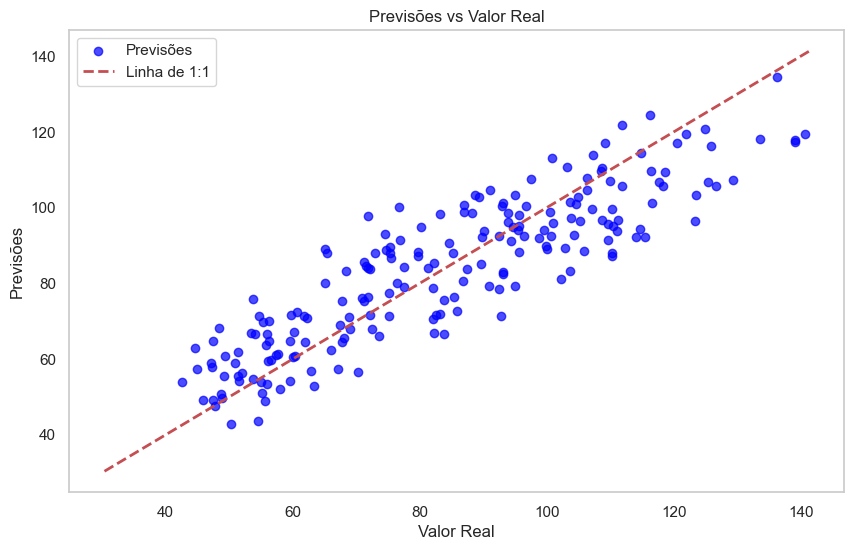

In [143]:
# Plotar Previsões vs Valor Real
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='blue', label='Previsões')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Linha de 1:1')
plt.xlabel('Valor Real')
plt.ylabel('Previsões')
plt.title('Previsões vs Valor Real')
plt.legend()
plt.grid()
plt.show()


### Modelo regressão logística

Index(['total', 'discount', 'quantity', 'rating', 'staff', 'total_bruto',
       'discount_percentage', 'quantity_discount_interaction', 'gender_Male',
       'payment_Credit'],
      dtype='object')
Relatório de classificação para dados de treino:
              precision    recall  f1-score   support

           0       0.82      0.83      0.83       397
           1       0.83      0.82      0.83       403

    accuracy                           0.83       800
   macro avg       0.83      0.83      0.83       800
weighted avg       0.83      0.83      0.83       800

Relatório de classificação para dados de teste:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86       104
           1       0.85      0.86      0.86        96

    accuracy                           0.86       200
   macro avg       0.86      0.86      0.86       200
weighted avg       0.86      0.86      0.86       200

Precisão no teste: 0.8469387755102041
Acurácia no

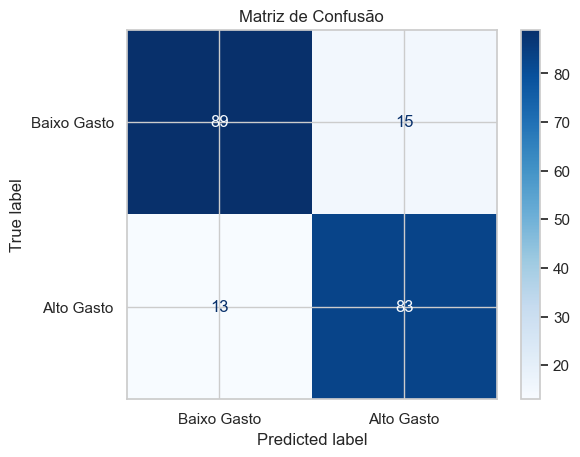

In [146]:
# Verificar se há variáveis categóricas para aplicar One-Hot Encoding
# Transformar as variáveis categóricas em dummies (one-hot encoding)
sales_encoded = pd.get_dummies(sales, drop_first=True)

# Verificar as novas colunas
print(sales_encoded.columns)

# Definir X e y (para o modelo de classificação, usaremos uma variável binária)
# Supondo que estamos tentando classificar entre valores de "total" acima de uma mediana como 1 (alto gasto) e abaixo da mediana como 0 (baixo gasto)
sales_encoded['total_class'] = (sales_encoded['total'] > sales_encoded['total'].median()).astype(int)

# Agora definimos X como todas as variáveis menos o 'total' e 'total_class'
X = sales_encoded.drop(columns=['total', 'total_class', 'total_bruto', 'discount_percentage', 'quantity_discount_interaction'])
y = sales_encoded['total_class']

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar o modelo de Regressão Logística
logistic_model = LogisticRegression(max_iter=1000)

# Treinar o modelo
logistic_model.fit(X_train, y_train)

# Fazer previsões
y_pred_train = logistic_model.predict(X_train)
y_pred_test = logistic_model.predict(X_test)

# Avaliar o modelo
print("Relatório de classificação para dados de treino:")
print(classification_report(y_train, y_pred_train))

print("Relatório de classificação para dados de teste:")
print(classification_report(y_test, y_pred_test))

# Acurácia do modelo
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)
# Calcular a precisão (precision) do modelo para o conjunto de teste
precision_test = precision_score(y_test, y_pred_test)
print(f"Precisão no teste: {precision_test}")

print(f'Acurácia no treino: {train_accuracy}')
print(f'Acurácia no teste: {test_accuracy}')

# Plotar a matriz de confusão
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Baixo Gasto", "Alto Gasto"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusão')
plt.show()



<Figure size 1000x600 with 0 Axes>

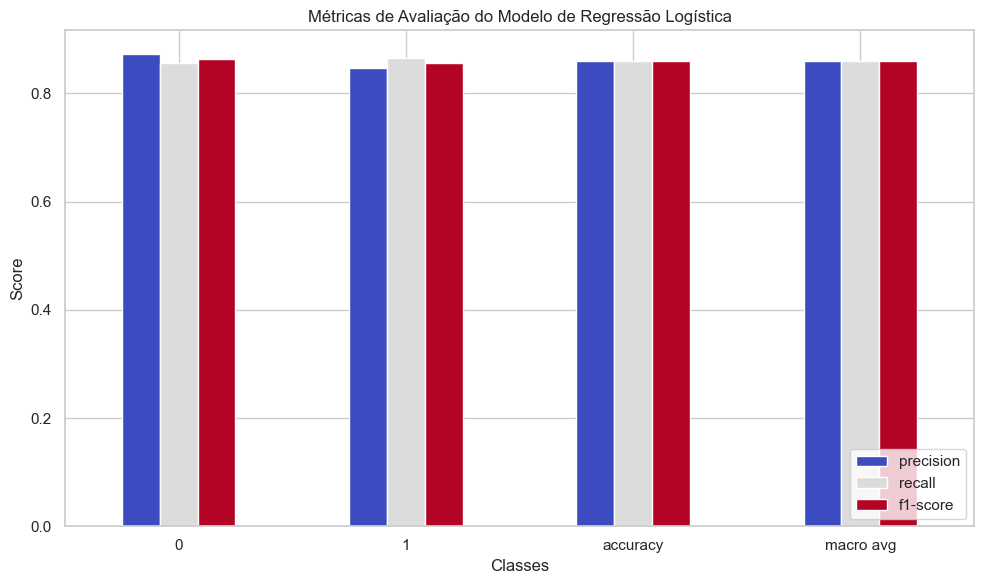

In [148]:
#Gerar o relatório de classificação
report = classification_report(y_test, y_pred_test, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Extraindo as métricas que você quer visualizar
df_metrics = df_report[['precision', 'recall', 'f1-score']].iloc[:-1]

# Plotar as métricas
plt.figure(figsize=(10, 6))
df_metrics.plot(kind='bar', figsize=(10, 6), colormap='coolwarm')

# Adicionar título e rótulos
plt.title('Métricas de Avaliação do Modelo de Regressão Logística')
plt.xlabel('Classes')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')

# Exibir o gráfico
plt.tight_layout()
plt.show()

## 6. Conclusão

O objetivo deste trabalho foi prever o valor total gasto por cliente em uma compra, com base num conjunto de variáveis fornecidas no dataset. Este problema, enquadrado na categoria de regressão, exigiu uma abordagem centrada na previsão de uma variável contínua. Para alcançar este objetivo, passámos por várias etapas importantes, incluindo aquisição de dados, limpeza e manipulação (Data Wrangling), análise exploratória de dados (EDA) e modelação preditiva.

Através do Data Wrangling, realizámos uma transformação essencial dos dados, criando novas variáveis e removendo entradas inconsistentes ou irrelevantes. Na análise exploratória de dados (EDA), identificámos relações relevantes entre as variáveis independentes e o valor total gasto, o que ajudou a direcionar o processo de modelação e a entender melhor o comportamento dos dados.

Durante a fase de modelação preditiva, utilizámos dois modelos principais: Regressão Linear e Regressão Logística.

A Regressão Linear foi aplicada para prever diretamente o valor total gasto, dada a natureza contínua da variável-alvo. Este modelo apresentou uma acurácia de __77%__ no treino e __77%__ no teste, demonstrando uma boa capacidade preditiva. O desempenho foi avaliado com o Erro Quadrático Médio (MSE), que foi de __118.25__ no treino e __131.45__ no teste, sugerindo que o modelo conseguiu capturar a maioria das tendências gerais no comportamento dos clientes, embora tenha enfrentado dificuldades em prever valores mais extremos ou anómalos.

A Regressão Logística, embora mais utilizada para problemas de classificação, foi aplicada aqui para classificar os clientes em diferentes faixas de gasto. O modelo alcançou uma acurácia de __83%__ no treino e __86%__ no teste, com um F1-score de __83__ no treino e __86__ no teste, mostrando um desempenho razoável na classificação. No entanto, a sua aplicação mostrou-se mais limitada neste contexto, uma vez que o problema principal envolvia a previsão de um valor contínuo.

Com base nos resultados, podemos concluir que a Regressão Linear se apresentou como o modelo mais apropriado para o objetivo do projeto, oferecendo uma precisão satisfatória tanto no conjunto de treino quanto no de teste. Embora a Regressão Logística tenha mostrado algum valor para cenários de classificação, a sua utilidade neste contexto foi mais restrita.

No geral, ao combinar técnicas de aprendizagem supervisionada com boas práticas de manipulação e análise de dados, foi possível construir modelos preditivos que oferecem previsões robustas e úteis sobre o comportamento de consumo dos clientes. Apesar de o modelo de Regressão Linear ter desempenhado bem, há espaço para melhorias futuras, como a inclusão de mais variáveis ou a utilização de modelos mais sofisticados. Contudo, os resultados obtidos até agora fornecem uma base sólida para a tomada de decisões informadas no contexto do comportamento de consumo.

Navlani, A., Fandango, A., & Idris, I. (2024). Python data analysis (3rd ed.). Packt Publishing.

VanderPlas, J. (2016). Python data science handbook: Essential tools for working with data. O'Reilly Media.